# Models Evaluation

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
import plotly.io as pio
import pickle

sns.set_style(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pio.renderers.default = "vscode"
pd.set_option('display.max_columns', None)

In [46]:
try:
    df = pd.read_csv('./preprocessed_cad.csv')
    df.columns = [c.lower() for c in df.columns]
    print(f"✅ Dataset Loaded: {df.shape[0]} patients, {df.shape[1]} columns.")
except FileNotFoundError:
    print("❌ Error. preprocessed_cad file not found")

✅ Dataset Loaded: 432 patients, 37 columns.


In [47]:
df.head()

,age,sex,bmi,current smoker,ex-smoker,fh,bp,pr,edema,weak peripheral pulse,lung rales,systolic murmur,diastolic murmur,typical chest pain,dyspnea,function class,atypical,q wave,st elevation,st depression,tinversion,lvh,poor r progression,fbs,cr,tg,ldl,hdl,bun,esr,ef-tte,region rwma,vhd,cath,cluster0,cluster1,cluster2
0,53,0,29.387755,1,0,0,110,80,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,90,0.7,250,155,30.0,8,7,50,0,0,1,0,0,1
1,67,1,28.398718,0,0,0,140,80,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,80,1.0,309,121,36.0,30,26,40,4,0,1,1,0,0
2,54,0,20.077335,1,0,0,100,100,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,85,1.0,103,70,45.0,17,10,40,2,1,1,1,0,0
3,66,1,26.838648,0,0,0,100,80,0,0,0,0,1,0,1,3,0,0,0,1,0,0,0,78,1.2,63,55,27.0,30,76,55,0,3,0,0,0,0
4,50,1,37.165193,0,0,0,110,80,0,0,0,1,0,0,1,2,0,0,0,0,0,0,0,104,1.0,170,110,50.0,16,27,50,0,3,0,0,0,0


In [48]:
X = df.drop('cath', axis=1)
y = df['cath']

In [49]:
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X,
                                                                            y,
                                                                            test_size=0.2,
                                                                            shuffle=True,
                                                                            stratify=y,
                                                                            random_state=42)

In [50]:
X_test_final.head()

,age,sex,bmi,current smoker,ex-smoker,fh,bp,pr,edema,weak peripheral pulse,lung rales,systolic murmur,diastolic murmur,typical chest pain,dyspnea,function class,atypical,q wave,st elevation,st depression,tinversion,lvh,poor r progression,fbs,cr,tg,ldl,hdl,bun,esr,ef-tte,region rwma,vhd,cluster0,cluster1,cluster2
187,70,0,24.280975,0,0,0,140,80,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,87,1.2,102,68,34.0,27,16,45,0,1,1,0,0
404,59,1,27.483034,0,1,0,113,70,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,85,1.2,184,104,49.6,21,13,50,0,1,0,1,0
425,52,0,28.488258,0,0,0,128,71,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,130,1.1,64,79,36.0,18,42,55,0,1,0,1,0
235,56,0,25.249337,1,0,1,130,80,0,0,0,0,0,1,1,2,0,0,0,0,1,0,0,90,1.2,210,170,46.0,15,3,45,3,0,1,0,0
407,37,1,30.317002,0,0,0,154,78,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,97,1.1,171,24,47.8,21,14,40,2,1,0,0,1


In [51]:
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bound_ = {}
        self.upper_bound_ = {}

    def fit(self, X, y=None):
        
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)

        for col in X.columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            self.lower_bound_[col] = Q1 - (self.factor * IQR)
            self.upper_bound_[col] = Q3 + (self.factor * IQR)
        return self

    def transform(self, X):
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)

        X_capped = X.copy()
        for col in X.columns:
            if col in self.lower_bound_:
                X_capped[col] = np.clip(X_capped[col], self.lower_bound_[col], self.upper_bound_[col])
        return X_capped.values 

print("✅'OutlierCapper' defined!")

✅'OutlierCapper' defined!


In [52]:
poly_log_reg_clf = pickle.load(open("./models/poly_log_reg.pkl", "rb"))
decision_tree_clf = pickle.load(open("./models/decision_tree.pkl", "rb"))
random_forest_clf = pickle.load(open("./models/random_forest.pkl", "rb"))
xgb_clf = pickle.load(open("./models/xgb_clf.pkl", "rb"))

## Polynomial Logistic Regresion Model Evaluation

In [53]:
from sklearn.metrics import confusion_matrix
y_pred_poly = poly_log_reg_clf.predict(X_test_final)
cm = confusion_matrix(y_test_final, y_pred_poly)

fig_cm = px.imshow(cm, text_auto=True, color_continuous_scale='Blues',
                   labels=dict(x="Prediction", y="Reality", color="Number of Patients"),
                   x=['Healthy', 'CAD'], y=['Healthy', 'CAD'],
                   title="Confusion Matrix : Poly-LogReg")
fig_cm.show()

📊 Performance report
✅ Precision: 92.31% -> How many of those classified as CAD patients are actualy sick?
✅ RECALL: 83.72% -> Of all real CAD patients, how many did we discover?
✅ SPECIFICITY: 93.18% -> How well the model is recognizing healthy people?
⚖️ F1-SCORE: 87.80% -> Harmonic mean between Precision and Recall.
------------------------------------------------------------
🔍 Error interpretation:
   - 3 False Positives
   - 7 False Negatives


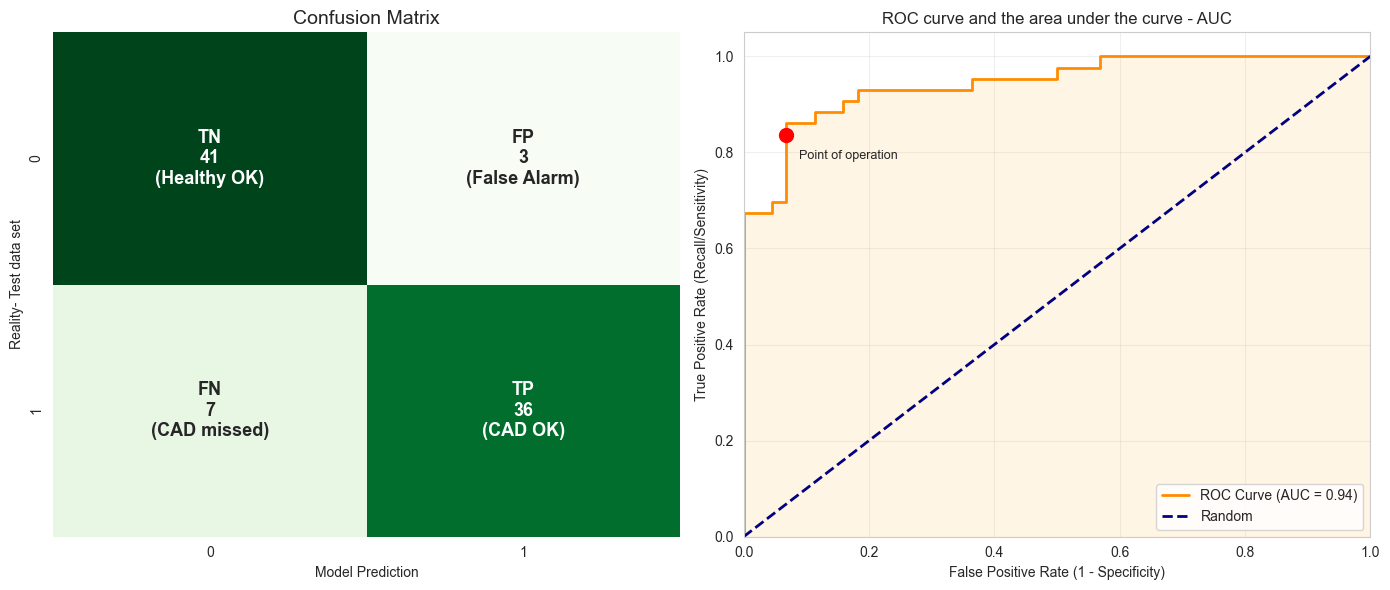

In [54]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


y_pred_final = poly_log_reg_clf.predict(X_test_final)

y_prob_final = poly_log_reg_clf.predict_proba(X_test_final)[:, 1]


cm = confusion_matrix(y_test_final, y_pred_final)
tn, fp, fn, tp = cm.ravel()


precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn)    if (tp + fn) > 0 else 0 
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


print("📊 Performance report")
print("="*60)
print(f"✅ Precision: {precision:.2%} -> How many of those classified as CAD patients are actualy sick?")
print(f"✅ RECALL: {recall:.2%} -> Of all real CAD patients, how many did we discover?")
print(f"✅ SPECIFICITY: {specificity:.2%} -> How well the model is recognizing healthy people?")
print(f"⚖️ F1-SCORE: {f1_score:.2%} -> Harmonic mean between Precision and Recall.")
print("-" * 60)
print(f"🔍 Error interpretation:")
print(f"   - {fp} False Positives")
print(f"   - {fn} False Negatives")
print("="*60)


plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
labels = [f"TN\n{tn}\n(Healthy OK)", f"FP\n{fp}\n(False Alarm)",
          f"FN\n{fn}\n(CAD missed)", f"TP\n{tp}\n(CAD OK)"]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Greens', cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Model Prediction")
plt.ylabel("Reality- Test data set")


fpr, tpr, thresholds = roc_curve(y_test_final, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='orange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('ROC curve and the area under the curve - AUC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


plt.scatter(1-specificity, recall, color='red', s=100, label='Current Model', zorder=5)
plt.text(1-specificity+0.02, recall-0.05, "Point of operation", fontsize=9)

plt.tight_layout()
plt.show()

## Polynomial Logistic Regresion Model Evaluation with custom threshold

📊 Performance report
✅ Precision:   67.21% -> How many of those classified as CAD patients are actualy sick?
✅ RECALL: 95.35% -> Of all real CAD patients, how many did we discover?
✅ SPECIFICITY:          54.55% -> How well the model is recognizing healthy people?
⚖️ F1-SCORE:               78.85% -> Harmonic mean between Precision and Recall.
------------------------------------------------------------
🔍 Error interpretation:
   - 20 False Positives
   - 2 False Negatives


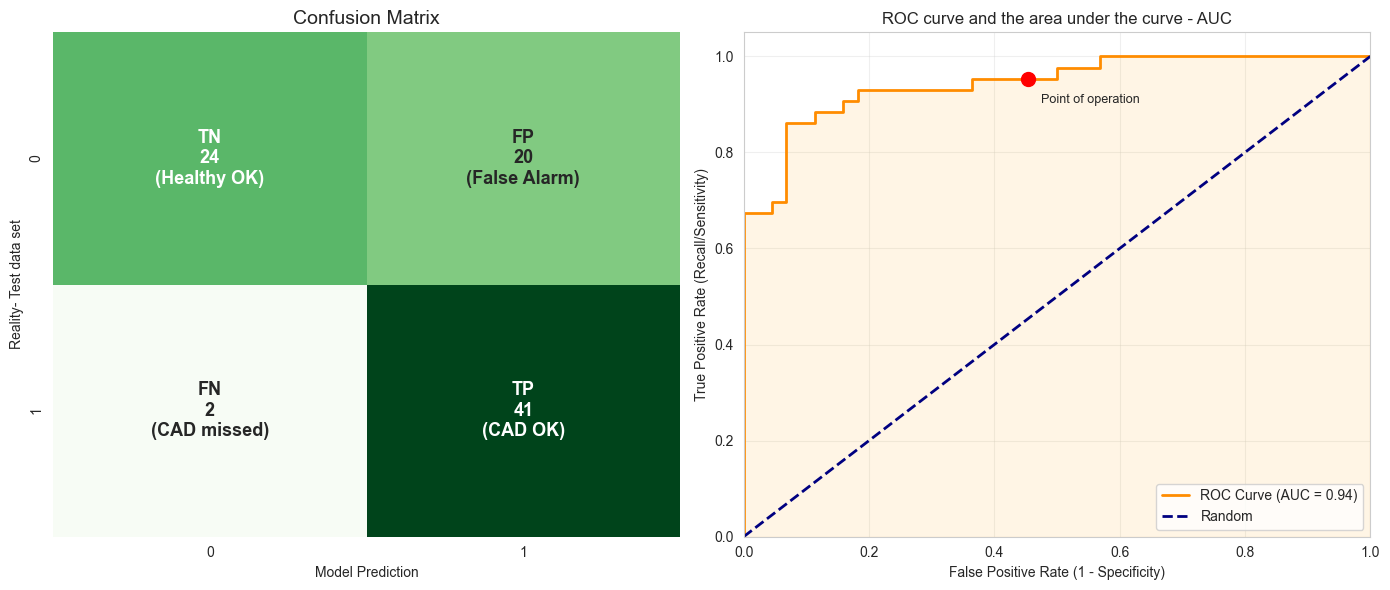

In [65]:
y_proba = poly_log_reg_clf.predict_proba(X_test_final)[:, 1] 

threshold = 0.15
y_pred_final = (y_proba >= threshold).astype(int)

y_prob_final = poly_log_reg_clf.predict_proba(X_test_final)[:, 1]


cm = confusion_matrix(y_test_final, y_pred_final)
tn, fp, fn, tp = cm.ravel()


precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn)    if (tp + fn) > 0 else 0 
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


print("📊 Performance report")
print("="*60)
print(f"✅ Precision:   {precision:.2%} -> How many of those classified as CAD patients are actualy sick?")
print(f"✅ RECALL: {recall:.2%} -> Of all real CAD patients, how many did we discover?")
print(f"✅ SPECIFICITY:          {specificity:.2%} -> How well the model is recognizing healthy people?")
print(f"⚖️ F1-SCORE:               {f1_score:.2%} -> Harmonic mean between Precision and Recall.")
print("-" * 60)
print(f"🔍 Error interpretation:")
print(f"   - {fp} False Positives")
print(f"   - {fn} False Negatives")
print("="*60)


plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
labels = [f"TN\n{tn}\n(Healthy OK)", f"FP\n{fp}\n(False Alarm)",
          f"FN\n{fn}\n(CAD missed)", f"TP\n{tp}\n(CAD OK)"]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Greens', cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Model Prediction")
plt.ylabel("Reality- Test data set")


fpr, tpr, thresholds = roc_curve(y_test_final, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='orange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('ROC curve and the area under the curve - AUC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


plt.scatter(1-specificity, recall, color='red', s=100, label='Current model', zorder=5)
plt.text(1-specificity+0.02, recall-0.05, "Point of operation", fontsize=9)

plt.tight_layout()
plt.show()

## Decision Tree model evaluation

📊 Performance report
✅ Precision: 86.84% -> How many of those classified as CAD patients are actualy sick?
✅ RECALL: 76.74% -> Of all real CAD patients, how many did we discover?
✅ SPECIFICITY: 88.64% -> How well the model is recognizing healthy people?
⚖️ F1-SCORE: 81.48% -> Harmonic mean between Precision and Recall.
------------------------------------------------------------
🔍 Error interpretation:
   - 5 False Positives
   - 10 False Negatives


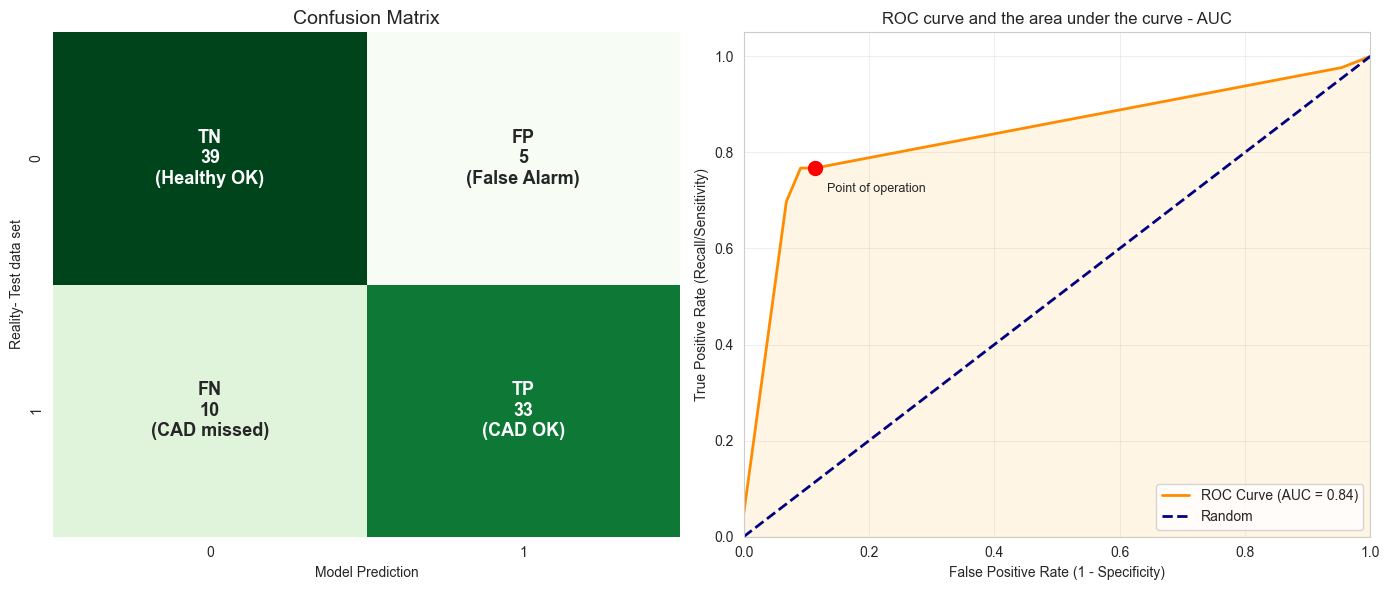

In [56]:
y_pred_final = decision_tree_clf.predict(X_test_final)

y_prob_final = decision_tree_clf.predict_proba(X_test_final)[:, 1]


cm = confusion_matrix(y_test_final, y_pred_final)
tn, fp, fn, tp = cm.ravel()


precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn)    if (tp + fn) > 0 else 0 
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


print("📊 Performance report")
print("="*60)
print(f"✅ Precision: {precision:.2%} -> How many of those classified as CAD patients are actualy sick?")
print(f"✅ RECALL: {recall:.2%} -> Of all real CAD patients, how many did we discover?")
print(f"✅ SPECIFICITY: {specificity:.2%} -> How well the model is recognizing healthy people?")
print(f"⚖️ F1-SCORE: {f1_score:.2%} -> Harmonic mean between Precision and Recall.")
print("-" * 60)
print(f"🔍 Error interpretation:")
print(f"   - {fp} False Positives")
print(f"   - {fn} False Negatives")
print("="*60)


plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
labels = [f"TN\n{tn}\n(Healthy OK)", f"FP\n{fp}\n(False Alarm)",
          f"FN\n{fn}\n(CAD missed)", f"TP\n{tp}\n(CAD OK)"]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Greens', cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Model Prediction")
plt.ylabel("Reality- Test data set")


fpr, tpr, thresholds = roc_curve(y_test_final, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='orange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('ROC curve and the area under the curve - AUC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


plt.scatter(1-specificity, recall, color='red', s=100, label='Current Model', zorder=5)
plt.text(1-specificity+0.02, recall-0.05, "Point of operation", fontsize=9)

plt.tight_layout()
plt.show()

## Decision Tree model evaluation with custom threshold

📊 Performance report
✅ Precision: 50.00% -> How many of those classified as CAD patients are actualy sick?
✅ RECALL: 97.67% -> Of all real CAD patients, how many did we discover?
✅ SPECIFICITY: 4.55% -> How well the model is recognizing healthy people?
⚖️ F1-SCORE: 66.14% -> Harmonic mean between Precision and Recall.
------------------------------------------------------------
🔍 Error interpretation:
   - 42 False Positives
   - 1 False Negatives


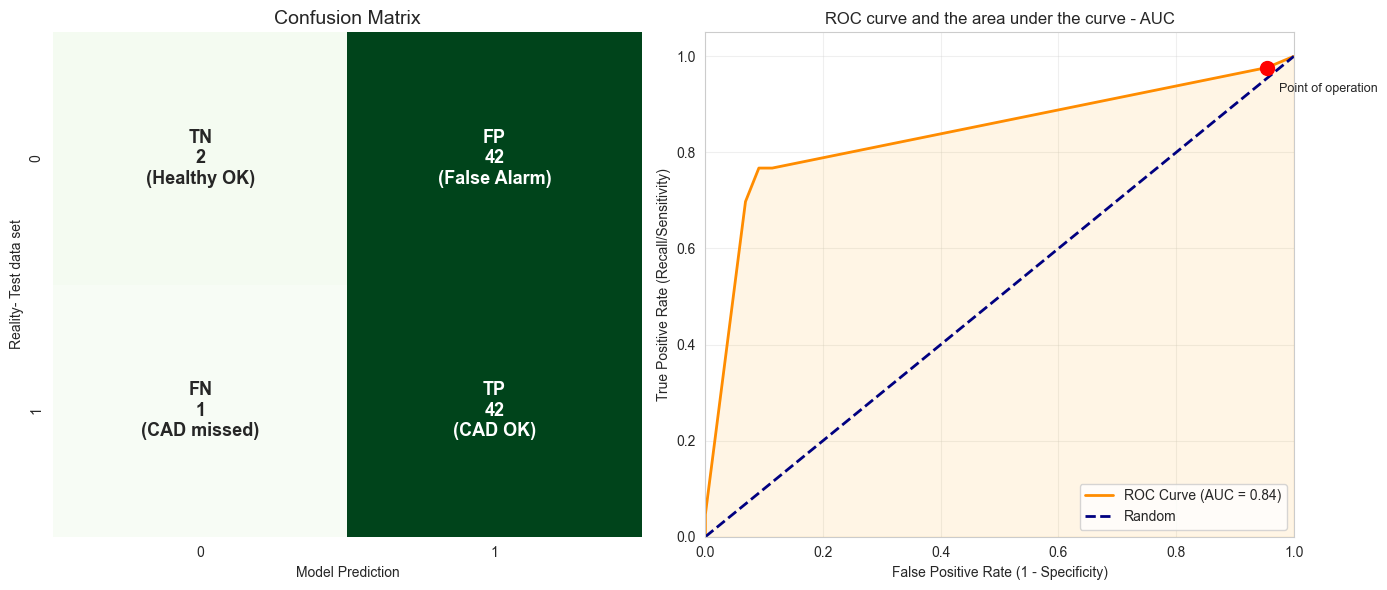

In [57]:
y_proba = decision_tree_clf.predict_proba(X_test_final)[:, 1] 
threshold = 0.1
y_pred_final = (y_proba >= threshold).astype(int)

y_prob_final = decision_tree_clf.predict_proba(X_test_final)[:, 1]


cm = confusion_matrix(y_test_final, y_pred_final)
tn, fp, fn, tp = cm.ravel()


precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn)    if (tp + fn) > 0 else 0 
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


print("📊 Performance report")
print("="*60)
print(f"✅ Precision: {precision:.2%} -> How many of those classified as CAD patients are actualy sick?")
print(f"✅ RECALL: {recall:.2%} -> Of all real CAD patients, how many did we discover?")
print(f"✅ SPECIFICITY: {specificity:.2%} -> How well the model is recognizing healthy people?")
print(f"⚖️ F1-SCORE: {f1_score:.2%} -> Harmonic mean between Precision and Recall.")
print("-" * 60)
print(f"🔍 Error interpretation:")
print(f"   - {fp} False Positives")
print(f"   - {fn} False Negatives")
print("="*60)


plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
labels = [f"TN\n{tn}\n(Healthy OK)", f"FP\n{fp}\n(False Alarm)",
          f"FN\n{fn}\n(CAD missed)", f"TP\n{tp}\n(CAD OK)"]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Greens', cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Model Prediction")
plt.ylabel("Reality- Test data set")


fpr, tpr, thresholds = roc_curve(y_test_final, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='orange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('ROC curve and the area under the curve - AUC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


plt.scatter(1-specificity, recall, color='red', s=100, label='Current Model', zorder=5)
plt.text(1-specificity+0.02, recall-0.05, "Point of operation", fontsize=9)

plt.tight_layout()
plt.show()

## Random Forest Model Evaluation

📊 Performance report
✅ Precision: 89.74% -> How many of those classified as CAD patients are actualy sick?
✅ RECALL: 81.40% -> Of all real CAD patients, how many did we discover?
✅ SPECIFICITY: 90.91% -> How well the model is recognizing healthy people?
⚖️ F1-SCORE: 85.37% -> Harmonic mean between Precision and Recall.
------------------------------------------------------------
🔍 Error interpretation:
   - 4 False Positives
   - 8 False Negatives


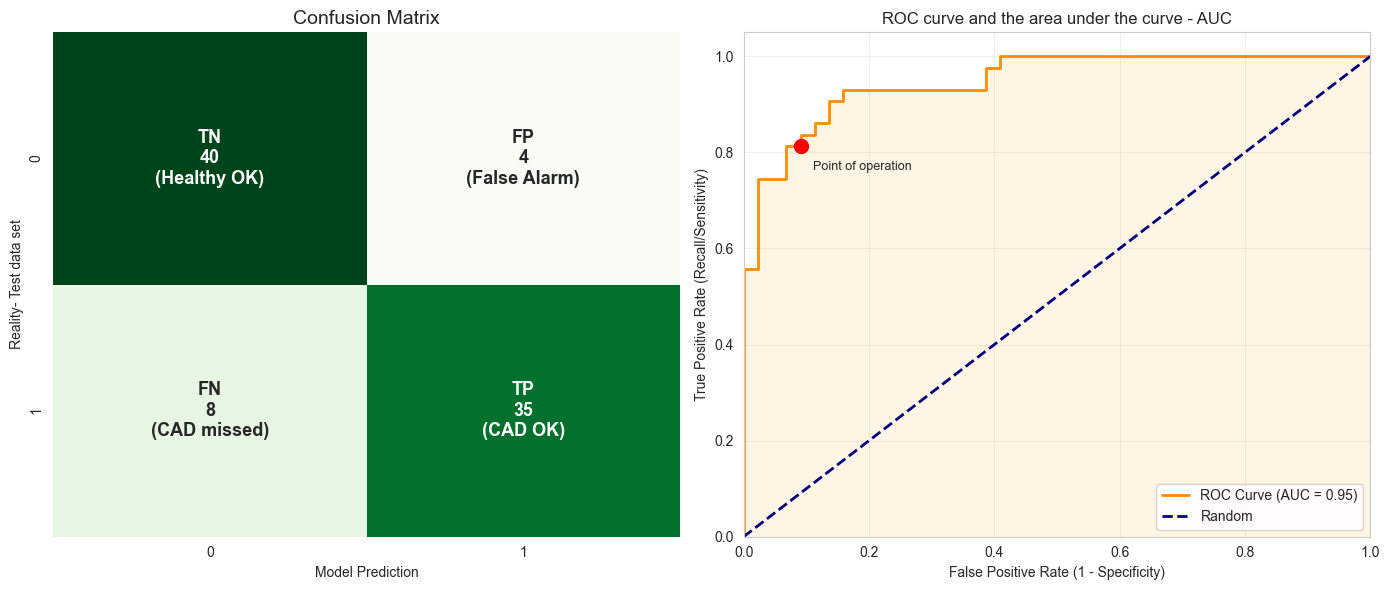

In [58]:
y_pred_final = random_forest_clf.predict(X_test_final)

y_prob_final = random_forest_clf.predict_proba(X_test_final)[:, 1]


cm = confusion_matrix(y_test_final, y_pred_final)
tn, fp, fn, tp = cm.ravel()


precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn)    if (tp + fn) > 0 else 0 
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


print("📊 Performance report")
print("="*60)
print(f"✅ Precision: {precision:.2%} -> How many of those classified as CAD patients are actualy sick?")
print(f"✅ RECALL: {recall:.2%} -> Of all real CAD patients, how many did we discover?")
print(f"✅ SPECIFICITY: {specificity:.2%} -> How well the model is recognizing healthy people?")
print(f"⚖️ F1-SCORE: {f1_score:.2%} -> Harmonic mean between Precision and Recall.")
print("-" * 60)
print(f"🔍 Error interpretation:")
print(f"   - {fp} False Positives")
print(f"   - {fn} False Negatives")
print("="*60)


plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
labels = [f"TN\n{tn}\n(Healthy OK)", f"FP\n{fp}\n(False Alarm)",
          f"FN\n{fn}\n(CAD missed)", f"TP\n{tp}\n(CAD OK)"]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Greens', cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Model Prediction")
plt.ylabel("Reality- Test data set")


fpr, tpr, thresholds = roc_curve(y_test_final, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='orange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('ROC curve and the area under the curve - AUC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


plt.scatter(1-specificity, recall, color='red', s=100, label='Current Model', zorder=5)
plt.text(1-specificity+0.02, recall-0.05, "Point of operation", fontsize=9)

plt.tight_layout()
plt.show()

## Random Forest Model Evaluation with custom Threshold

📊 Performance report
✅ Precision: 70.49% -> How many of those classified as CAD patients are actualy sick?
✅ RECALL: 100.00% -> Of all real CAD patients, how many did we discover?
✅ SPECIFICITY: 59.09% -> How well the model is recognizing healthy people?
⚖️ F1-SCORE: 82.69% -> Harmonic mean between Precision and Recall.
------------------------------------------------------------
🔍 Error interpretation:
   - 18 False Positives
   - 0 False Negatives


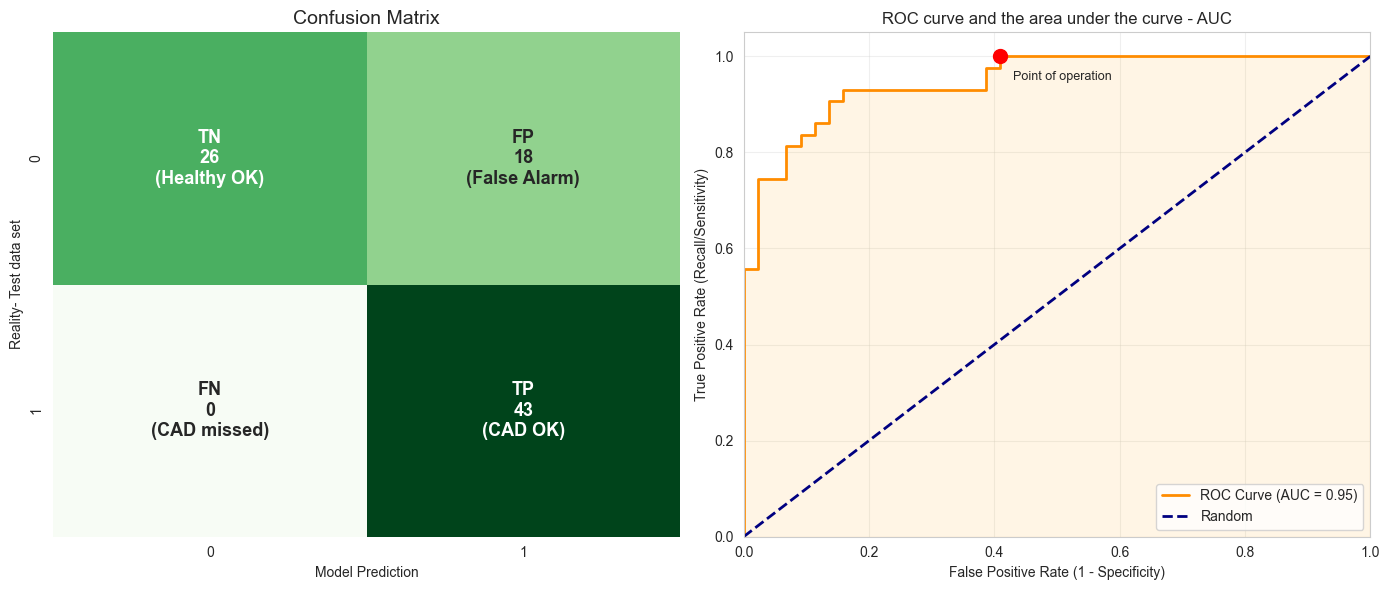

In [100]:
y_proba = random_forest_clf.predict_proba(X_test_final)[:, 1] 
threshold = 0.17
y_pred_final = (y_proba >= threshold).astype(int)

y_prob_final = random_forest_clf.predict_proba(X_test_final)[:, 1]


cm = confusion_matrix(y_test_final, y_pred_final)
tn, fp, fn, tp = cm.ravel()


precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn)    if (tp + fn) > 0 else 0 
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


print("📊 Performance report")
print("="*60)
print(f"✅ Precision: {precision:.2%} -> How many of those classified as CAD patients are actualy sick?")
print(f"✅ RECALL: {recall:.2%} -> Of all real CAD patients, how many did we discover?")
print(f"✅ SPECIFICITY: {specificity:.2%} -> How well the model is recognizing healthy people?")
print(f"⚖️ F1-SCORE: {f1_score:.2%} -> Harmonic mean between Precision and Recall.")
print("-" * 60)
print(f"🔍 Error interpretation:")
print(f"   - {fp} False Positives")
print(f"   - {fn} False Negatives")
print("="*60)


plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
labels = [f"TN\n{tn}\n(Healthy OK)", f"FP\n{fp}\n(False Alarm)",
          f"FN\n{fn}\n(CAD missed)", f"TP\n{tp}\n(CAD OK)"]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Greens', cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Model Prediction")
plt.ylabel("Reality- Test data set")


fpr, tpr, thresholds = roc_curve(y_test_final, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='orange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('ROC curve and the area under the curve - AUC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


plt.scatter(1-specificity, recall, color='red', s=100, label='Current Model', zorder=5)
plt.text(1-specificity+0.02, recall-0.05, "Point of operation", fontsize=9)

plt.tight_layout()
plt.show()

## Polynomial Logistic Regression and Random Forest models Ensemble Evaluation

📊 Performance report
✅ Precision: 65.62% -> How many of those classified as CAD patients are actualy sick?
✅ RECALL: 97.67% -> Of all real CAD patients, how many did we discover?
✅ SPECIFICITY: 50.00% -> How well the model is recognizing healthy people?
⚖️ F1-SCORE: 78.50% -> Harmonic mean between Precision and Recall.
------------------------------------------------------------
🔍 Error interpretation:
   - 22 False Positives
   - 1 False Negatives


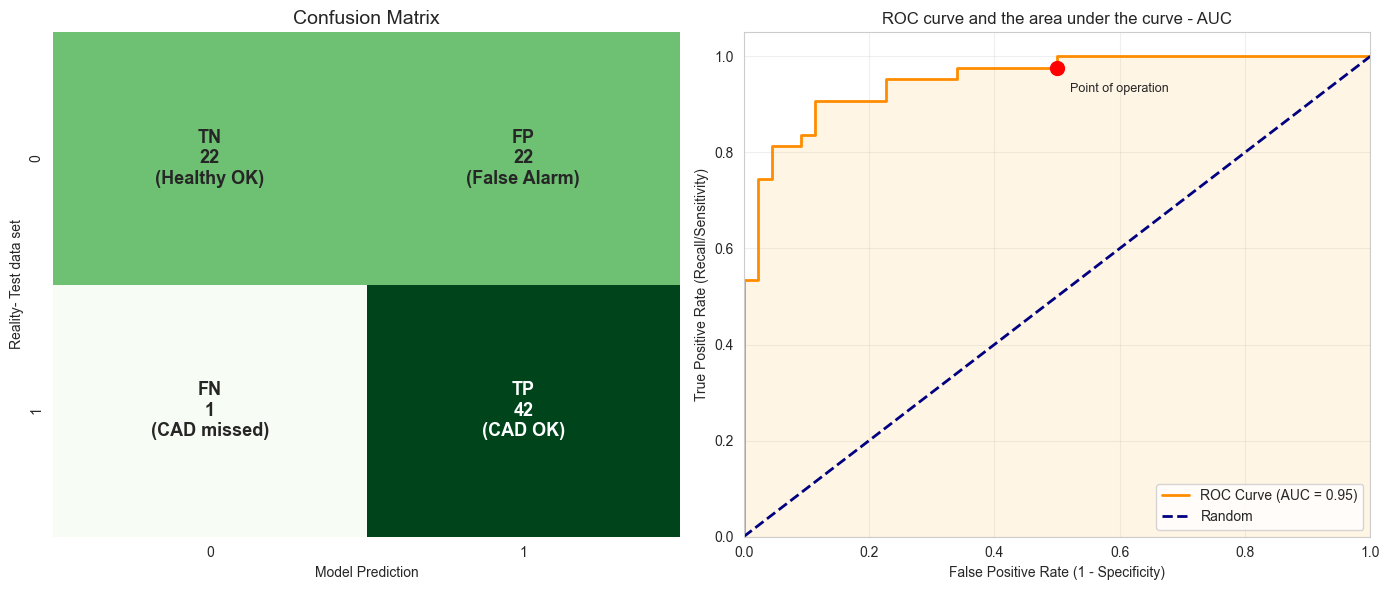

In [76]:
y_proba1 = poly_log_reg_clf.predict_proba(X_test_final)[:, 1] 
y_proba2 = random_forest_clf.predict_proba(X_test_final)[:, 1] 
combined_prob = (y_proba1 + y_proba2) / 2

y_pred_final = (combined_prob >= 0.15).astype(int)

y_prob_final = y_prob_final = combined_prob


cm = confusion_matrix(y_test_final, y_pred_final)
tn, fp, fn, tp = cm.ravel()


precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn)    if (tp + fn) > 0 else 0 
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


print("📊 Performance report")
print("="*60)
print(f"✅ Precision: {precision:.2%} -> How many of those classified as CAD patients are actualy sick?")
print(f"✅ RECALL: {recall:.2%} -> Of all real CAD patients, how many did we discover?")
print(f"✅ SPECIFICITY: {specificity:.2%} -> How well the model is recognizing healthy people?")
print(f"⚖️ F1-SCORE: {f1_score:.2%} -> Harmonic mean between Precision and Recall.")
print("-" * 60)
print(f"🔍 Error interpretation:")
print(f"   - {fp} False Positives")
print(f"   - {fn} False Negatives")
print("="*60)


plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
labels = [f"TN\n{tn}\n(Healthy OK)", f"FP\n{fp}\n(False Alarm)",
          f"FN\n{fn}\n(CAD missed)", f"TP\n{tp}\n(CAD OK)"]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Greens', cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Model Prediction")
plt.ylabel("Reality- Test data set")


fpr, tpr, thresholds = roc_curve(y_test_final, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='orange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('ROC curve and the area under the curve - AUC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


plt.scatter(1-specificity, recall, color='red', s=100, label='Current Model', zorder=5)
plt.text(1-specificity+0.02, recall-0.05, "Point of operation", fontsize=9)

plt.tight_layout()
plt.show()

## XGBoost Model Evaluation

📊 Performance report
✅ Precision: 90.24% -> How many of those classified as CAD patients are actualy sick?
✅ RECALL: 86.05% -> Of all real CAD patients, how many did we discover?
✅ SPECIFICITY: 90.91% -> How well the model is recognizing healthy people?
⚖️ F1-SCORE: 88.10% -> Harmonic mean between Precision and Recall.
------------------------------------------------------------
🔍 Error interpretation:
   - 4 False Positives
   - 6 False Negatives


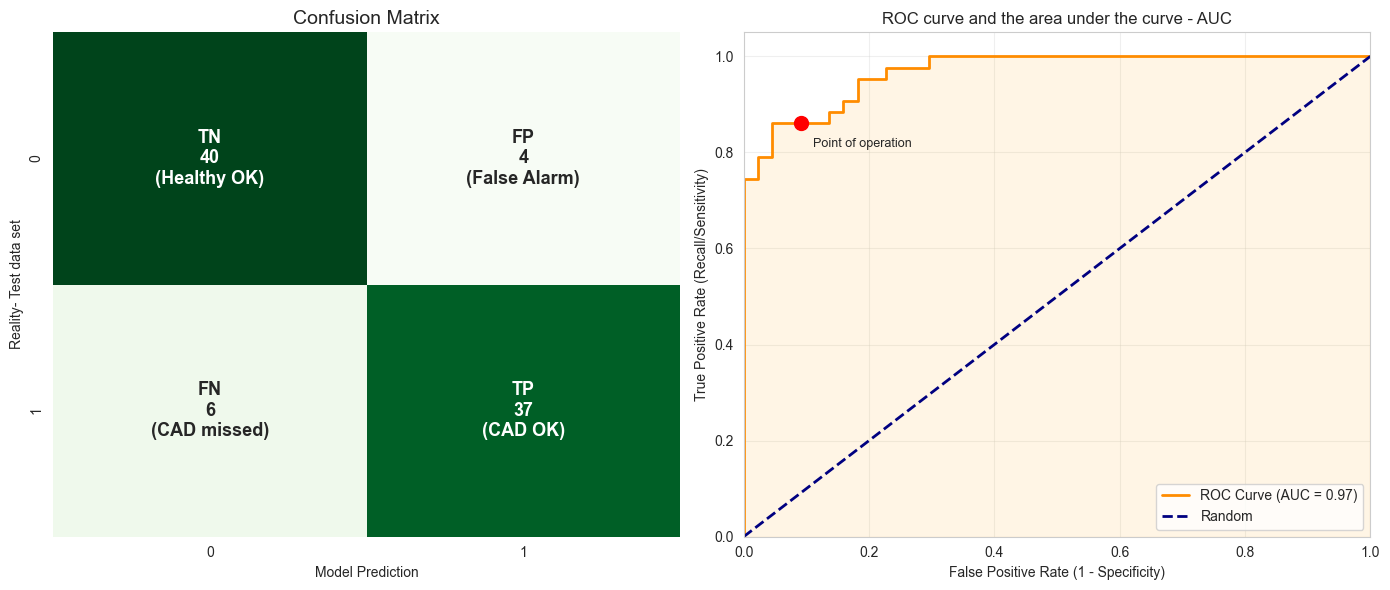

In [61]:
y_pred_final = xgb_clf.predict(X_test_final)

y_prob_final = xgb_clf.predict_proba(X_test_final)[:, 1]


cm = confusion_matrix(y_test_final, y_pred_final)
tn, fp, fn, tp = cm.ravel()


precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn)    if (tp + fn) > 0 else 0 
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


print("📊 Performance report")
print("="*60)
print(f"✅ Precision: {precision:.2%} -> How many of those classified as CAD patients are actualy sick?")
print(f"✅ RECALL: {recall:.2%} -> Of all real CAD patients, how many did we discover?")
print(f"✅ SPECIFICITY: {specificity:.2%} -> How well the model is recognizing healthy people?")
print(f"⚖️ F1-SCORE: {f1_score:.2%} -> Harmonic mean between Precision and Recall.")
print("-" * 60)
print(f"🔍 Error interpretation:")
print(f"   - {fp} False Positives")
print(f"   - {fn} False Negatives")
print("="*60)


plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
labels = [f"TN\n{tn}\n(Healthy OK)", f"FP\n{fp}\n(False Alarm)",
          f"FN\n{fn}\n(CAD missed)", f"TP\n{tp}\n(CAD OK)"]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Greens', cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Model Prediction")
plt.ylabel("Reality- Test data set")


fpr, tpr, thresholds = roc_curve(y_test_final, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='orange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('ROC curve and the area under the curve - AUC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


plt.scatter(1-specificity, recall, color='red', s=100, label='Current Model', zorder=5)
plt.text(1-specificity+0.02, recall-0.05, "Point of operation", fontsize=9)

plt.tight_layout()
plt.show()

## XGB Model evaluation with custom threshold

📊 Performance report
✅ Precision: 76.79% -> How many of those classified as CAD patients are actualy sick?
✅ RECALL: 100.00% -> Of all real CAD patients, how many did we discover?
✅ SPECIFICITY: 70.45% -> How well the model is recognizing healthy people?
⚖️ F1-SCORE: 86.87% -> Harmonic mean between Precision and Recall.
------------------------------------------------------------
🔍 Error interpretation:
   - 13 False Positives
   - 0 False Negatives


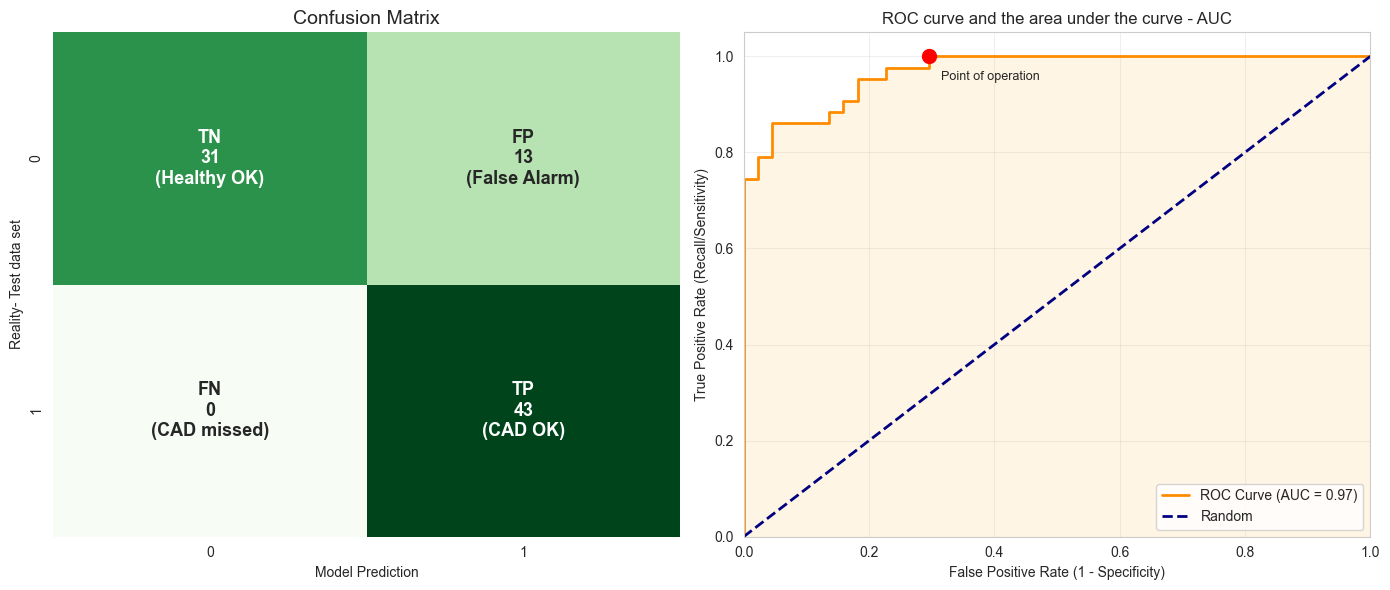

In [81]:
y_proba = xgb_clf.predict_proba(X_test_final)[:, 1] 
threshold = 0.13
y_pred_final = (y_proba >= threshold).astype(int)

y_prob_final = xgb_clf.predict_proba(X_test_final)[:, 1]


cm = confusion_matrix(y_test_final, y_pred_final)
tn, fp, fn, tp = cm.ravel()


precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn)    if (tp + fn) > 0 else 0 
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


print("📊 Performance report")
print("="*60)
print(f"✅ Precision: {precision:.2%} -> How many of those classified as CAD patients are actualy sick?")
print(f"✅ RECALL: {recall:.2%} -> Of all real CAD patients, how many did we discover?")
print(f"✅ SPECIFICITY: {specificity:.2%} -> How well the model is recognizing healthy people?")
print(f"⚖️ F1-SCORE: {f1_score:.2%} -> Harmonic mean between Precision and Recall.")
print("-" * 60)
print(f"🔍 Error interpretation:")
print(f"   - {fp} False Positives")
print(f"   - {fn} False Negatives")
print("="*60)


plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
labels = [f"TN\n{tn}\n(Healthy OK)", f"FP\n{fp}\n(False Alarm)",
          f"FN\n{fn}\n(CAD missed)", f"TP\n{tp}\n(CAD OK)"]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Greens', cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Model Prediction")
plt.ylabel("Reality- Test data set")


fpr, tpr, thresholds = roc_curve(y_test_final, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='orange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('ROC curve and the area under the curve - AUC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


plt.scatter(1-specificity, recall, color='red', s=100, label='Current Model', zorder=5)
plt.text(1-specificity+0.02, recall-0.05, "Point of operation", fontsize=9)

plt.tight_layout()
plt.show()

## Polynomial Logistic Regression and XGBoost models Ensemble Evaluation

📊 Performance report
✅ Precision: 67.74% -> How many of those classified as CAD patients are actualy sick?
✅ RECALL: 97.67% -> Of all real CAD patients, how many did we discover?
✅ SPECIFICITY: 54.55% -> How well the model is recognizing healthy people?
⚖️ F1-SCORE: 80.00% -> Harmonic mean between Precision and Recall.
------------------------------------------------------------
🔍 Error interpretation:
   - 20 False Positives
   - 1 False Negatives


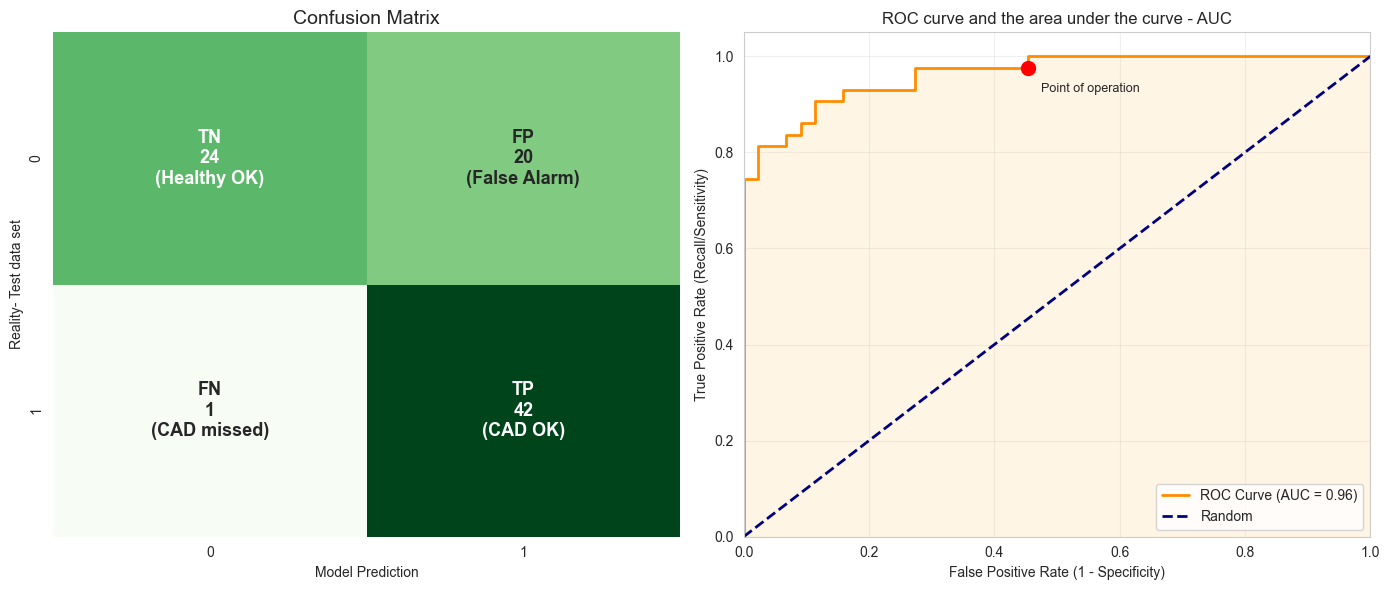

In [85]:
y_proba1 = poly_log_reg_clf.predict_proba(X_test_final)[:, 1] 
y_proba2 = xgb_clf.predict_proba(X_test_final)[:, 1] 
combined_prob = (y_proba1 + y_proba2) / 2

y_pred_final = (combined_prob >= 0.12).astype(int)

y_prob_final = y_prob_final = combined_prob


cm = confusion_matrix(y_test_final, y_pred_final)
tn, fp, fn, tp = cm.ravel()


precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn)    if (tp + fn) > 0 else 0 
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


print("📊 Performance report")
print("="*60)
print(f"✅ Precision: {precision:.2%} -> How many of those classified as CAD patients are actualy sick?")
print(f"✅ RECALL: {recall:.2%} -> Of all real CAD patients, how many did we discover?")
print(f"✅ SPECIFICITY: {specificity:.2%} -> How well the model is recognizing healthy people?")
print(f"⚖️ F1-SCORE: {f1_score:.2%} -> Harmonic mean between Precision and Recall.")
print("-" * 60)
print(f"🔍 Error interpretation:")
print(f"   - {fp} False Positives")
print(f"   - {fn} False Negatives")
print("="*60)


plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
labels = [f"TN\n{tn}\n(Healthy OK)", f"FP\n{fp}\n(False Alarm)",
          f"FN\n{fn}\n(CAD missed)", f"TP\n{tp}\n(CAD OK)"]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Greens', cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Model Prediction")
plt.ylabel("Reality- Test data set")


fpr, tpr, thresholds = roc_curve(y_test_final, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='orange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('ROC curve and the area under the curve - AUC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


plt.scatter(1-specificity, recall, color='red', s=100, label='Current Model', zorder=5)
plt.text(1-specificity+0.02, recall-0.05, "Point of operation", fontsize=9)

plt.tight_layout()
plt.show()

## Polynomial Logistic Regression, Decision Tree, Random Forest and XGBoost models Ensemble Evaluation

📊 Performance report
✅ Precision: 76.36% -> How many of those classified as CAD patients are actualy sick?
✅ RECALL: 97.67% -> Of all real CAD patients, how many did we discover?
✅ SPECIFICITY: 70.45% -> How well the model is recognizing healthy people?
⚖️ F1-SCORE: 85.71% -> Harmonic mean between Precision and Recall.
------------------------------------------------------------
🔍 Error interpretation:
   - 13 False Positives
   - 1 False Negatives


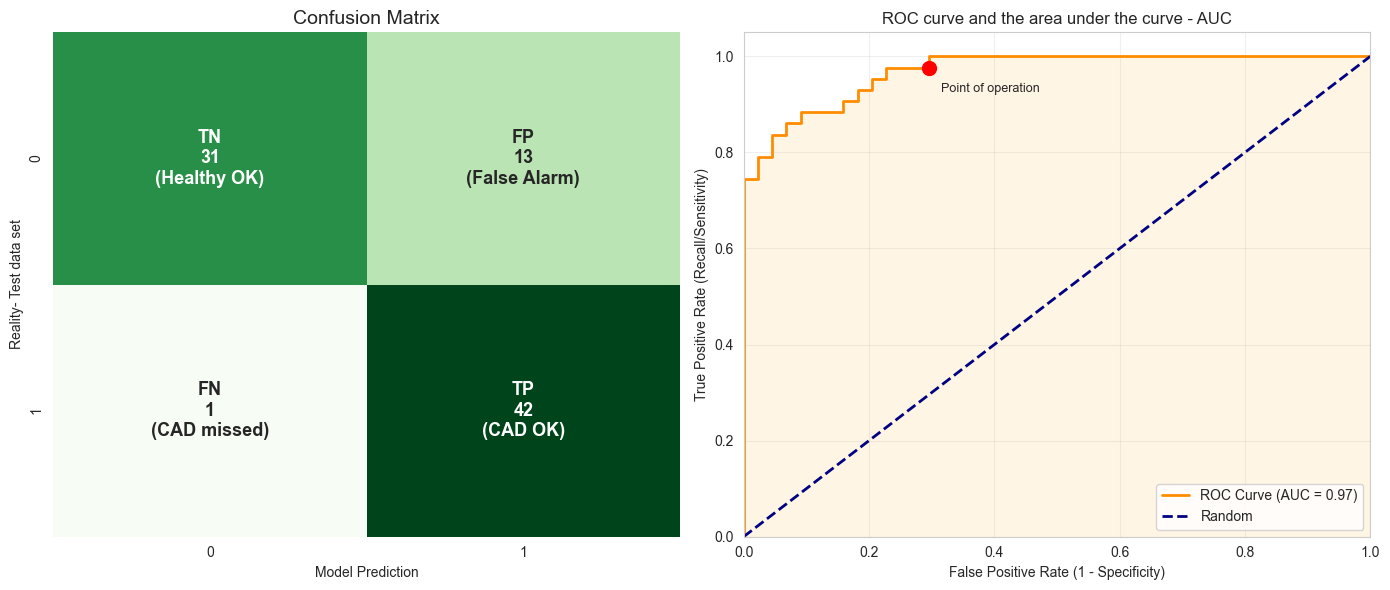

In [102]:
y_proba1 = poly_log_reg_clf.predict_proba(X_test_final)[:, 1] 
y_proba2 = decision_tree_clf.predict_proba(X_test_final)[:, 1] 
y_proba3 = random_forest_clf.predict_proba(X_test_final)[:, 1] 
y_proba4 = xgb_clf.predict_proba(X_test_final)[:, 1] 
combined_prob = ( 0.0 * y_proba1 + 0.0 * y_proba2 + 0.1 * y_proba3 + 0.9 *  y_proba4) 

y_pred_final = (combined_prob >= 0.14).astype(int)

y_prob_final = y_prob_final = combined_prob


cm = confusion_matrix(y_test_final, y_pred_final)
tn, fp, fn, tp = cm.ravel()


precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn)    if (tp + fn) > 0 else 0 
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


print("📊 Performance report")
print("="*60)
print(f"✅ Precision: {precision:.2%} -> How many of those classified as CAD patients are actualy sick?")
print(f"✅ RECALL: {recall:.2%} -> Of all real CAD patients, how many did we discover?")
print(f"✅ SPECIFICITY: {specificity:.2%} -> How well the model is recognizing healthy people?")
print(f"⚖️ F1-SCORE: {f1_score:.2%} -> Harmonic mean between Precision and Recall.")
print("-" * 60)
print(f"🔍 Error interpretation:")
print(f"   - {fp} False Positives")
print(f"   - {fn} False Negatives")
print("="*60)


plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
labels = [f"TN\n{tn}\n(Healthy OK)", f"FP\n{fp}\n(False Alarm)",
          f"FN\n{fn}\n(CAD missed)", f"TP\n{tp}\n(CAD OK)"]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Greens', cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Model Prediction")
plt.ylabel("Reality- Test data set")


fpr, tpr, thresholds = roc_curve(y_test_final, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='orange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('ROC curve and the area under the curve - AUC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)


plt.scatter(1-specificity, recall, color='red', s=100, label='Current Model', zorder=5)
plt.text(1-specificity+0.02, recall-0.05, "Point of operation", fontsize=9)

plt.tight_layout()
plt.show()

### BEST model: XGBoost
- RECALL 100%
- BEST Precision of al models
- BEST Specificity of all models